In [5]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import json

ROOT = Path("/content/drive/MyDrive/Speaker_Recognition_System")
FEATURES = ROOT / "data/features"
META = ROOT / "metadata"

EMBED_PATH = FEATURES / "X_embeddings.npy"
LABEL_PATH = FEATURES / "y_labels.npy"
DB_PATH = META / "familiar_db.json"

print("✅ Updated paths loaded")
print("Embeddings:", EMBED_PATH.exists(), "Labels:", LABEL_PATH.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Updated paths loaded
Embeddings: True Labels: True


In [7]:
import numpy as np
from pathlib import Path

embeddings = np.load(EMBED_PATH)
labels = np.load(LABEL_PATH)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)
print("✔ Data Loaded")


Embeddings shape: (496, 1, 192)
Labels shape: (496,)
✔ Data Loaded


In [9]:
# Fix embedding shape: (N, T, 192) -> (N, 192)

if embeddings.ndim == 3:
    print("Fixing shape: Averaging across time frames")
    embeddings = embeddings.mean(axis=1)

    # Save fixed version back to drive
    np.save(EMBED_PATH, embeddings)

print("New shape:", embeddings.shape)


Fixing shape: Averaging across time frames
New shape: (496, 192)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_train, y_train)

print("Classifier trained ✅")


Classifier trained ✅


In [11]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9919
F1 Score: 0.6667

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       122
           1       1.00      0.50      0.67         2

    accuracy                           0.99       124
   macro avg       1.00      0.75      0.83       124
weighted avg       0.99      0.99      0.99       124

Confusion Matrix:
 [[122   0]
 [  1   1]]


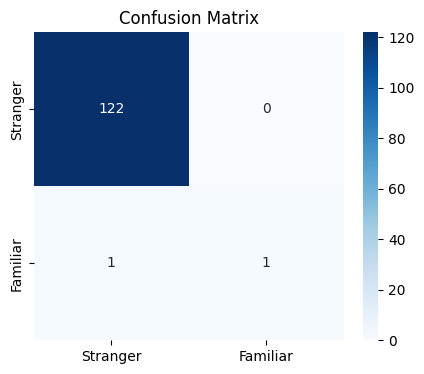

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stranger", "Familiar"],
            yticklabels=["Stranger", "Familiar"])
plt.title("Confusion Matrix")
plt.show()


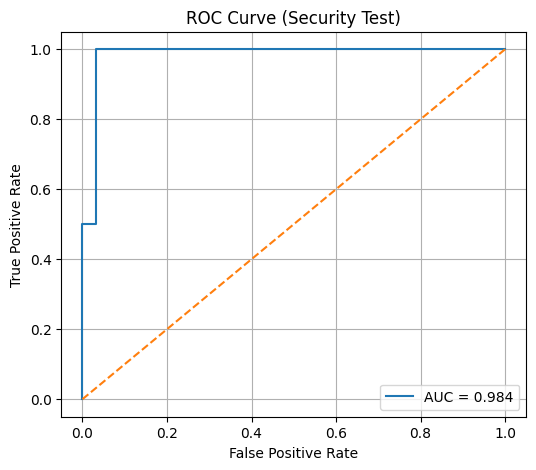

AUC-ROC: 0.9836065573770492


In [13]:
from sklearn.metrics import roc_curve, auc

y_prob = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Security Test)")
plt.legend()
plt.grid()
plt.show()

print("AUC-ROC:", roc_auc)


In [14]:
fnr = 1 - tpr
eer_index = np.nanargmin(np.abs(fnr - fpr))
EER = (fpr[eer_index] + fnr[eer_index]) / 2
optimal_threshold = thresholds[eer_index]

print(" Equal Error Rate (EER):", round(EER, 4))
print("Best Threshold:", round(float(optimal_threshold), 4))


 Equal Error Rate (EER): 0.0164
Best Threshold: 0.0


In [15]:
security_data = {
    "THRESHOLD": round(float(optimal_threshold), 4),
    "EER": round(float(EER), 4),
    "ROC_AUC": round(float(roc_auc), 4)
}

with open(ROOT / "metadata/security_metrics.json", "w") as f:
    json.dump(security_data, f, indent=4)

print("✅ Security metrics saved to security_metrics.json")


✅ Security metrics saved to security_metrics.json


In [16]:
print("---- Security Assessment ----")
print(f"EER {EER:.3f} → Lower is better\n")

if EER <= 0.05:
    print("✅ Very Strong — Near zero impersonation risk")
elif EER <= 0.10:
    print("✅ Strong — Good real-world performance")
elif EER <= 0.20:
    print("⚠ Medium — Might allow clever attacker with similar voice")
else:
    print("⛔ Weak — Must improve model / dataset")


---- Security Assessment ----
EER 0.016 → Lower is better

✅ Very Strong — Near zero impersonation risk
